In [82]:
# first and foremost: importing the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Task 1

In [83]:
tallest = pd.read_csv('tallest_people_in_the_world.csv')

In [84]:
tallest.head(10)

,id,name,gender,country,continent,height_cm,height_ft_in,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
0,1,John F. Carroll,Male,USA,North America,264,8 ft 8 in,140.0,1932,1969.0,37,NaN,Acromegaly,0
1,2,Robert Wadlow,Male,USA,North America,272,8 ft 11 in,199.0,1918,1940.0,22,Entertainer,Gigantism,0
2,3,John Rogan,Male,USA,North America,267,8 ft 9 in,79.0,1868,1905.0,37,Seller,Gigantism,0
3,4,Willie Camper,Male,USA,North America,260,8 ft 6.3 in,170.0,1924,1943.0,18,Entertainer,Gigantism,0
4,5,Siah Khan,Male,Iran,Asia,259,8 ft 6 in,155.0,1913,1939.0,26,Entertainer,Gigantism,0
5,6,Akashi Shiganosuke,Male,Japan,Asia,254,8 ft 4 in,185.0,1600,1649.0,49,Athlete,Gigantism,0
6,7,Vrolijk de Beers,Male,Malawi,Africa,246,8 ft 1 in,130.0,1925,1961.0,36,Entertainer,Gigantism,0
7,8,Ho Van Trung,Male,Vietnam,Asia,257,8 ft 5 in,158.0,1984,2019.0,35,Farmer,Gigantism,0
8,9,Pornchai Saosri,Male,Thailand,Asia,269,8 ft 10 in,NaN,1989,2015.0,26,NaN,Gigantism,0
9,10,Bernard Coyne,Male,USA,North America,249,8 ft 2 in,NaN,1897,1921.0,24,NaN,Gigantism,0


### 1.1

In [85]:
tallest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 157 non-null    int64  
 1   name               157 non-null    object 
 2   gender             157 non-null    object 
 3   country            157 non-null    object 
 4   continent          157 non-null    object 
 5   height_cm          157 non-null    int64  
 6   height_ft_in       157 non-null    object 
 7   weight_kg          74 non-null     float64
 8   birth_year         157 non-null    int64  
 9   death_year         84 non-null     float64
 10  lifespan           157 non-null    int64  
 11  occupation         111 non-null    object 
 12  medical_condition  157 non-null    object 
 13  is_alive           157 non-null    int64  
dtypes: float64(2), int64(5), object(7)
memory usage: 17.3+ KB


So there is 14 attributes, including an id.

1. **name** - nominal. It has no order and each field have distinct category.
2. **gender** - nominal. No order and distinct category.
3. **country** - nominal. No quantitative data present here and no meaningful order, so yea, again, it's nominal.
4. **continent** - nominal. Same as previous three.
5. **height_cm** - continuous. Height is measured, it's in form of fractional numbers.
6. **height_ft_in** - continuous. No difference to attribute presented above.
7. **weight_kg** - continuous. Again, weight as a height can take any value and can be quantified with decimal precision.
8. **birth_year** - discrete. It's compromised of only integer or whole numbers and needs to be counted, in contrary to continuous data.
9. **death_year** - discrete. Same as birth_year.
10. **lifespan** - discrete. It shows how many years person lived before death. No fractional numbers here, because fields are whole years of lifespan; so, discrete.
11. **occupation** - nominal. Attribute states of what profession person had. It's categorical and no particular order here.
12. **medical_condition** - nominal. No order here, so nominal.
13. **is_alive** - nominal or binary. It has only two possible values: true or false (alive or not alive). These are categories, not numerical measurements and there is no magnitude or order between them.

### 1.2

1) Calculating a central tendency includes mean, median, mode, range, variance, standard deviation and IQR. Let's do this on height in cm of tallest people.

In [86]:
stats = {
    "mean": tallest['height_cm'].mean(),
    "median": tallest['height_cm'].median(),
    "mode": tallest['height_cm'].mode()[0],
    "range": tallest['height_cm'].max() - tallest['height_cm'].min(),
    "variance": tallest['height_cm'].var(),
    "std_dev": tallest['height_cm'].std(),
    "Q1": tallest['height_cm'].quantile(0.25),
    "Q3": tallest['height_cm'].quantile(0.75),
    "IQR": tallest['height_cm'].quantile(0.75) - tallest['height_cm'].quantile(0.25)
}

print(stats)


{'mean': np.float64(233.9044585987261), 'median': np.float64(233.0), 'mode': np.int64(221), 'range': np.int64(62), 'variance': np.float64(139.2536338396211), 'std_dev': np.float64(11.800577690927724), 'Q1': np.float64(224.0), 'Q3': np.float64(241.0), 'IQR': np.float64(17.0)}


Or we can do describe.

In [87]:
tallest['height_cm'].describe()

count    157.000000
mean     233.904459
std       11.800578
min      210.000000
25%      224.000000
50%      233.000000
75%      241.000000
max      272.000000
Name: height_cm, dtype: float64

2) Now, to show outliers it's best to use boxplot for effectively visualizing our outliers here in terms of height.

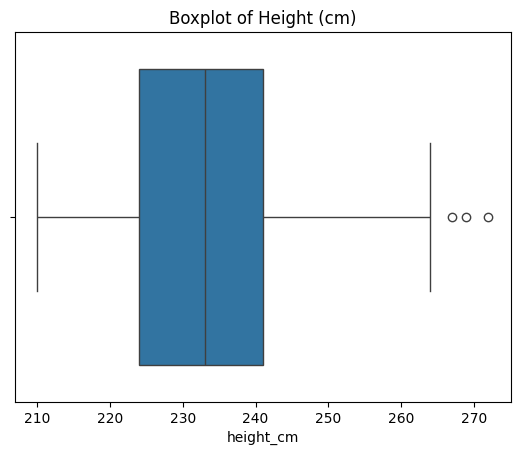

In [88]:
sns.boxplot(x=tallest["height_cm"])
plt.title("Boxplot of Height (cm)")
plt.show()


It shows here that our median is 233. There are about three clear upper outliers. Let's chekc value for our upper bound. Formula is Upper bound = Q3 + 1.5 × IQR. So, our upper limit equals to 241 + 1.5 x 17 = **265.5**. Upper outliers' values is in interval of upper bound and maximum value, so it's between **265.5 and 272**.  No lower outliers are present.

### 1.3

1) Dataset has missing values in **weight** feature. We will apply imputation methods (Constant value, Mean/Median/Mode, Predictive imputation (e.g regression or KNN)) on this column.

Let's get original values beforehand.

In [89]:
# number of missing values in weight_kg
print("Number of missing values:", tallest['weight_kg'].isnull().sum())

Number of missing values: 83


In [90]:
# mean of weight_kg
print("Mean:", tallest['weight_kg'].mean())

Mean: 143.94594594594594


In [91]:
# standard deviation of weight_kg
print("Standard Deviation:", tallest['weight_kg'].std())

Standard Deviation: 34.046258576612075


2) Now let's try to implement imputation methods to oppose missing values.

In [92]:
# Constant Value Imputation
# impute
tallest['weight_kg'] = tallest['weight_kg'].fillna(-1)

# check for parameters
print("Mean:", tallest['weight_kg'].mean())
print("Standard Deviation:", tallest['weight_kg'].std())

Mean: 67.31847133757962
Standard Deviation: 76.23025496485752


In [93]:
tallest = pd.read_csv('tallest_people_in_the_world.csv')  # reset it

In [94]:
# Mean Value Imputation
# impute
tallest['weight_kg'] = tallest['weight_kg'].fillna(tallest['weight_kg'].mean())

# check for parameters
print("Mean:", tallest['weight_kg'].mean())
print("Standard Deviation:", tallest['weight_kg'].std())

Mean: 143.94594594594594
Standard Deviation: 23.28994828078609


In [95]:
tallest = pd.read_csv('tallest_people_in_the_world.csv')  # reset it

In [96]:
# KNN Imputation
# importing here
from sklearn.impute import SimpleImputer, KNNImputer

#impute
tallest[['weight_kg', 'height_cm', 'birth_year', 'lifespan']] = KNNImputer(n_neighbors=5).fit_transform(tallest[['weight_kg', 'height_cm', 'birth_year', 'lifespan']])

# check for parameters
print("Mean:", tallest['weight_kg'].mean())
print("Standard Deviation:", tallest['weight_kg'].std())

Mean: 146.6407643312102
Standard Deviation: 28.02195786323604


In [97]:
tallest = pd.read_csv('tallest_people_in_the_world.csv')  # reset it

Best one here is K-Nearest Neighbor method, which is not surprising, because of close to orignal mean and lost less variance than Mean Imputation method.

Constant value method is quick and easy and it's best used to when missing data has a meaning or to point out missing values.
Mean/Mode/Median value method is good, but creates artificial spikes in stats.
KNN method finds the most similar people and averages values. It have good stats, but significantly slower.

## Task 2

### 2.1 

Let's use height_cm and weight_kg for the distribution and relationship analysis

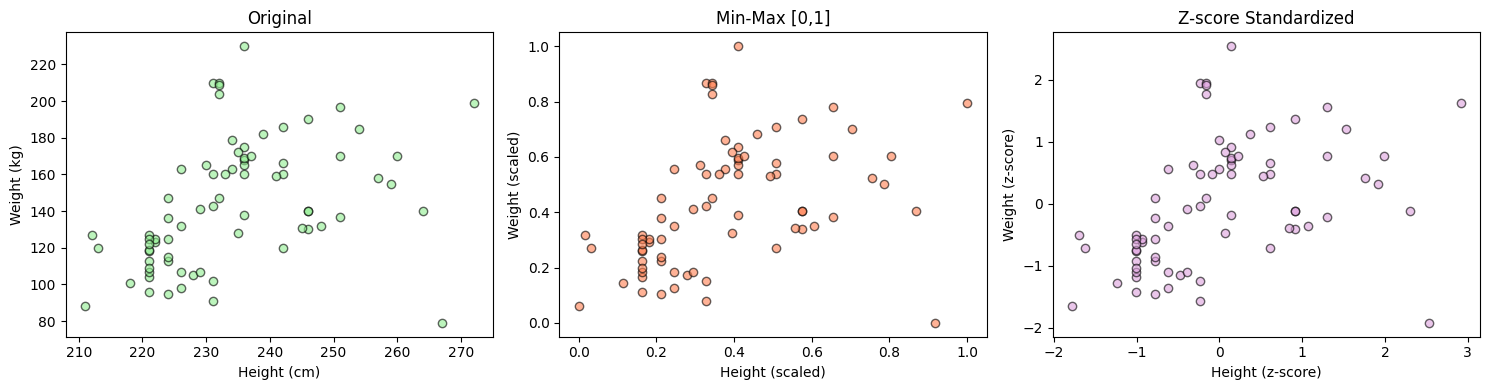

In [105]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# loaded data again for readability (used tallest in place of tallest for better usability)
tallest = pd.read_csv('tallest_people_in_the_world.csv')
tallest_clean = tallest[['height_cm', 'weight_kg']].dropna()

# scaling
tallest_minmax = pd.DataFrame(MinMaxScaler().fit_transform(tallest_clean), columns=tallest_clean.columns)
tallest_zscore = pd.DataFrame(StandardScaler().fit_transform(tallest_clean), columns=tallest_clean.columns)

# scatter plots
plt.figure(figsize=(15, 4))

# original
plt.subplot(1, 3, 1)
plt.scatter(tallest_clean['height_cm'], tallest_clean['weight_kg'], color='lightgreen', ec='black', alpha=0.6)
plt.title('Original')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')

# min-max one
plt.subplot(1, 3, 2)
plt.scatter(tallest_minmax['height_cm'], tallest_minmax['weight_kg'], color='coral', ec='black', alpha=0.6)
plt.title('Min-Max [0,1]')
plt.xlabel('Height (scaled)')
plt.ylabel('Weight (scaled)')

# z-scored one
plt.subplot(1, 3, 3)
plt.scatter(tallest_zscore['height_cm'], tallest_zscore['weight_kg'], color='plum', ec='black', alpha=0.6)
plt.title('Z-score Standardized')
plt.xlabel('Height (z-score)')
plt.ylabel('Weight (z-score)')

# presto!
plt.tight_layout()
plt.show()

As we can see, we reshaped weight_kg and height_cm features by normalizing them using min-max and z-score. Now for use cases: min-max works best in bounded data and neural networks, while z-score normalization in outlier-rich data and in clustering processes.

### 2.2

1) Let's create new feature. In domain logic, best suited here is BMI. It is abbreviation for Body Mass Index and formula for it BMI = weight(kg) / height(m)^2. The BMI is a convenient rule of thumb used to broadly categorize a person as based on tissue mass (Wikipedia).

In [103]:
tallest['height_m'] = tallest['height_cm'] / 100  # converting cm to meters for formula 
tallest['BMI'] = tallest['weight_kg'] / (tallest['height_m'] ** 2)

In [104]:
tallest['BMI'].describe()

count    74.000000
mean     26.195402
std       5.539016
min      11.081654
25%      22.010196
50%      25.718546
75%      29.732597
max      41.295605
Name: BMI, dtype: float64

2) Now for binnings

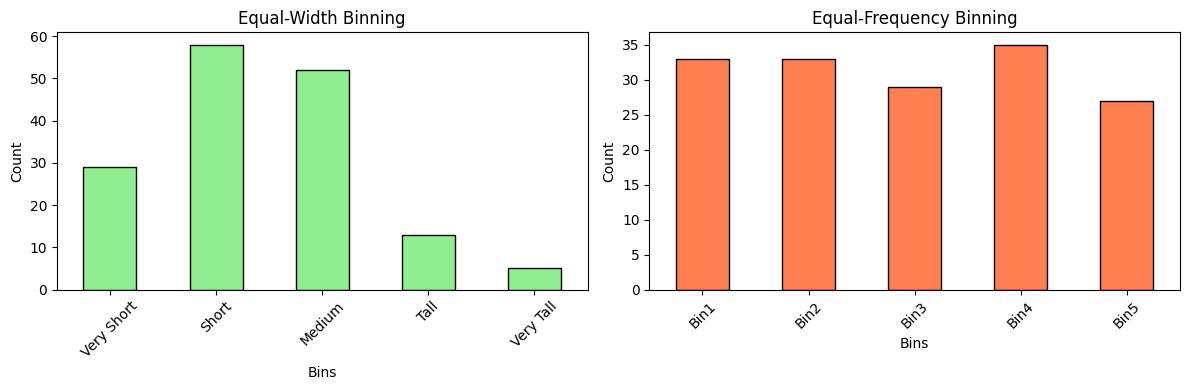

In [108]:
# remove missing values for clean binning
tallest_binning = tallest[['height_cm']].dropna()

# Equal-Width Binning (same range size)
tallest_binning['height_equal_width'], bins_width = pd.cut(
    tallest_binning['height_cm'], 
    bins=5, 
    retbins=True,
    labels=['Very Short', 'Short', 'Medium', 'Tall', 'Very Tall']
)

# Equal-Frequency Binning (same count per bin)
tallest_binning['height_equal_freq'], bins_freq = pd.qcut(
    tallest_binning['height_cm'], 
    q=5, 
    retbins=True,
    labels=['Bin1', 'Bin2', 'Bin3', 'Bin4', 'Bin5'],
    duplicates='drop'
)

# visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tallest_binning['height_equal_width'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Equal-Width Binning')
axes[0].set_xlabel('Bins')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

tallest_binning['height_equal_freq'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Equal-Frequency Binning')
axes[1].set_xlabel('Bins')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()